# 

In [1]:
import os 
os.environ['KMP_DUPLICATE_LIB_OK'] = "TRUE"

import torch
import torch.nn.functional as F

In [2]:
import matplotlib.pyplot as plt 
%matplotlib inline

In [3]:
file = open("input.txt" , 'r')
content = file.read()
sentences = content.splitlines()

words= []
for sentence in sentences:
    word =sentence.split()
    words.extend(word)

unique_words = sorted(list(set(words)))
unique_words[:10]

['&C:', '&c.', "'", "'?", "'A", "'Alas,", "'Alas,'", "'Alla", "'An", "'Ay"]

In [16]:
len(unique_words)

25670

In [4]:
#mapping

stoi = {s :i+1 for i , s in enumerate(unique_words)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}

In [5]:
#building the dataset

def build_dataset(sentences):
    context_window = 4
    X , Y  = [] , []
    
    for sentence in sentences[:]:
        words = sentence.split()
        context = [0]*context_window
        chs = words+["."]
        for ch in chs:
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape , Y.shape)
    return X , Y


import random 
random.seed(2047)
random.shuffle(sentences)

n1 = int(0.8*(len(sentences)))
n2=  int(0.9*(len(sentences)))

Xtr , Ytr = build_dataset(sentences[:n1])
Xval , Yval = build_dataset(sentences[n1:n2])
Xtest , Ytest = build_dataset(sentences[n2:])

torch.Size([193487, 4]) torch.Size([193487])
torch.Size([24889, 4]) torch.Size([24889])
torch.Size([24275, 4]) torch.Size([24275])


In [51]:
#parameters 
g = torch.Generator().manual_seed(2407)
C = torch.randn((len(unique_words)+1 , 40) , generator = g)
emb = C[Xtr]
emb.shape
W1 = torch.randn((160 , 200) , generator= g)
b1 = torch.randn(200 , generator = g )
W2 = torch.randn((200 , len(unique_words)+1) , generator= g)*0.01 ###### doubt - why did the loss decrease as soon as i decreased the weights too much
#was the model overfitting or what 
b2 = torch.randn((len(unique_words)+1) , generator= g)
parameters = [C , W1 , b1 , b2 , W2 ]
sum(p.nelement() for p in parameters)#13 million parameters
emb.shape

##weight decay penality to prevent overfitting -
lambda_wd = 1e-8 

for p in parameters:
  p.requires_grad = True

#### why one should have a small model and not a fairly large model ?

1) having a model of the apt size and not a fairly large models prevent overfitting - think of it like a shelf
2) a shelf with a lot of shelves in it would store more information - similarly a model which is of a fairly large size would store a heck lot of information in it - leading it to memorise this information which would eventually lead to overfitting which is something which we dont want
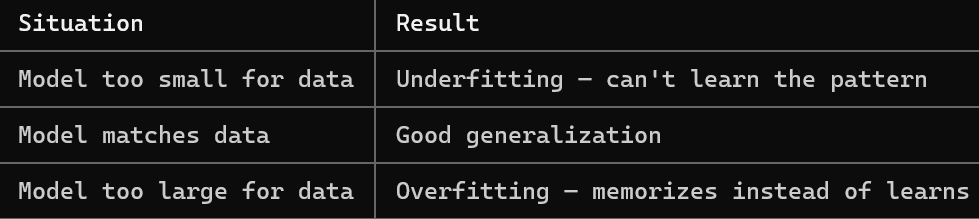

so the rule of thumb is always use the apt size of model 

if you have a really large dataset - u can afford a bigger model 
if you have a fairly small dataset having such big of a model is not something which we might want
if you have an infinite dataset - well then it is difficult for the model to even overfit

In [52]:
#figuring out the learning rate
lre = torch.linspace(-3 , 0 ,1000)
lrs = 10**lre

In [53]:
lri = []
lossi =  []


In [54]:
for i in range(1000):
  #minibatch construction
  ix = torch.randint(0 , Xtr.shape[0] , (2500 ,) , generator= g)

  #the forward pass 
  emb = C[Xtr[ix]]

  h = torch.tanh(emb.view(emb.shape[0] , emb.shape[1]*emb.shape[2])@W1 + b1)
  logits = h@W2+b2 
  loss = F.cross_entropy(logits, Ytr[ix])
  loss+= lambda_wd*((W1**2).sum() + (W2**2).sum())#implementing the weigght decay penality - this is a bug - raw weights can be negative - so sum ther squared

  #the backward pass
  for p in parameters:
    p.grad = None

  loss.backward()
  lossi.append(loss.item())

    
  #the data update
  lr =lrs[i]
  lri.append(lre[i]) 
  for p in parameters:
    p.data += -lr*p.grad

print(loss.item())


KeyboardInterrupt: 

In [ ]:
plt.plot(lri , lossi)#finding the loss using the graphing technique

In [ ]:
emb = C[Xtr[ix]]
h = torch.tanh(emb.view(emb.shape[0] , emb.shape[1]*emb.shape[2])@W1 + b1)
logits = h@W2+b2 
loss = F.cross_entropy(logits, Ytr[ix])
loss

In [ ]:
ix = torch.randint(0 , Xval.shape[0] , (2500 ,) , generator= g)
emb = C[Xval[ix]]

h = torch.tanh(emb.view(emb.shape[0] , emb.shape[1]*emb.shape[2])@W1 + b1)
logits = h@W2+b2 
loss = F.cross_entropy(logits, Yval[ix])
####this is throwing up an error -
loss